In [28]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [29]:
ksp_db = pd.read_csv("../../datasets/ks-projects-201612.csv", encoding="cp1252", low_memory=False)
ksp_db.head()

,ID,name,category,main_category,currency,deadline,goal,launched,pledged,state,backers,country,usd pledged,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16
0,1000002330,The Songs of Adelaide & Abullah,Poetry,Publishing,GBP,2015-10-09 11:36:00,1000,2015-08-11 12:12:28,0,failed,0,GB,0,NaN,NaN,NaN,NaN
1,1000004038,Where is Hank?,Narrative Film,Film & Video,USD,2013-02-26 00:20:50,45000,2013-01-12 00:20:50,220,failed,3,US,220,NaN,NaN,NaN,NaN
2,1000007540,ToshiCapital Rekordz Needs Help to Complete Album,Music,Music,USD,2012-04-16 04:24:11,5000,2012-03-17 03:24:11,1,failed,1,US,1,NaN,NaN,NaN,NaN
3,1000011046,Community Film Project: The Art of Neighborhoo...,Film & Video,Film & Video,USD,2015-08-29 01:00:00,19500,2015-07-04 08:35:03,1283,canceled,14,US,1283,NaN,NaN,NaN,NaN
4,1000014025,Monarch Espresso Bar,Restaurants,Food,USD,2016-04-01 13:38:27,50000,2016-02-26 13:38:27,52375,successful,224,US,52375,NaN,NaN,NaN,NaN


In [30]:
ksp_db.info()

<class 'pandas.DataFrame'>
RangeIndex: 323750 entries, 0 to 323749
Data columns (total 17 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   ID              323750 non-null  int64  
 1   name            323746 non-null  str    
 2   category        323745 non-null  str    
 3   main_category   323750 non-null  str    
 4   currency        323750 non-null  str    
 5   deadline        323750 non-null  str    
 6   goal            323750 non-null  str    
 7   launched        323750 non-null  str    
 8   pledged         323750 non-null  str    
 9   state           323750 non-null  str    
 10  backers         323750 non-null  str    
 11  country         323750 non-null  str    
 12  usd pledged     319960 non-null  str    
 13  Unnamed: 13     625 non-null     str    
 14  Unnamed: 14     12 non-null      str    
 15  Unnamed: 15     4 non-null       str    
 16  Unnamed: 16     1 non-null       float64
dtypes: float64(1), int64(

In [31]:
ksp_db.dropna()
ksp_db.isnull().sum()

ID                     0
name                   4
category               5
main_category          0
currency               0
deadline               0
goal                   0
launched               0
pledged                0
state                  0
backers                0
country                0
usd pledged         3790
Unnamed: 13       323125
Unnamed: 14       323738
Unnamed: 15       323746
Unnamed: 16       323749
dtype: int64

In [32]:
print(ksp_db.columns.values)

newColnames = []

for i in range(len(ksp_db.columns.values)):
    newColnames.append(ksp_db.columns.values[i][:len(ksp_db.columns.values[i]) - 1])
ksp_db.columns = newColnames
ksp_db.head()
print(ksp_db.columns)

<StringArray>
[           'ID ',          'name ',      'category ', 'main_category ',
      'currency ',      'deadline ',          'goal ',      'launched ',
       'pledged ',         'state ',       'backers ',       'country ',
   'usd pledged ',    'Unnamed: 13',    'Unnamed: 14',    'Unnamed: 15',
    'Unnamed: 16']
Length: 17, dtype: str
Index(['ID', 'name', 'category', 'main_category', 'currency', 'deadline',
       'goal', 'launched', 'pledged', 'state', 'backers', 'country',
       'usd pledged', 'Unnamed: 1', 'Unnamed: 1', 'Unnamed: 1', 'Unnamed: 1'],
      dtype='str')


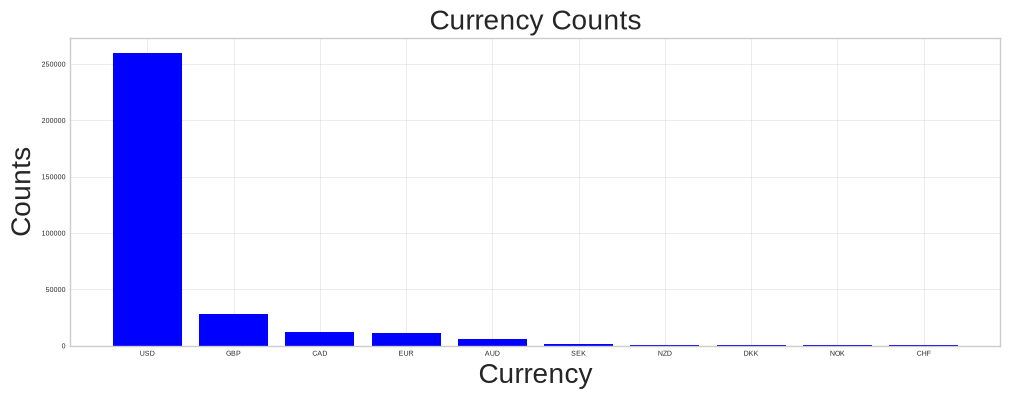

In [33]:
ks_cnt_cur = ksp_db.groupby('currency')['currency'].count().sort_values(ascending=False).head(10)

plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(12, 4))
plt.bar(ks_cnt_cur.index.values, ks_cnt_cur.values, color="blue")
plt.xticks(fontsize=5)
plt.yticks(fontsize=5)

plt.title('Currency Counts', fontsize=20)
plt.xlabel('Currency', fontsize=20)
plt.ylabel('Counts', fontsize=20)
plt.show()

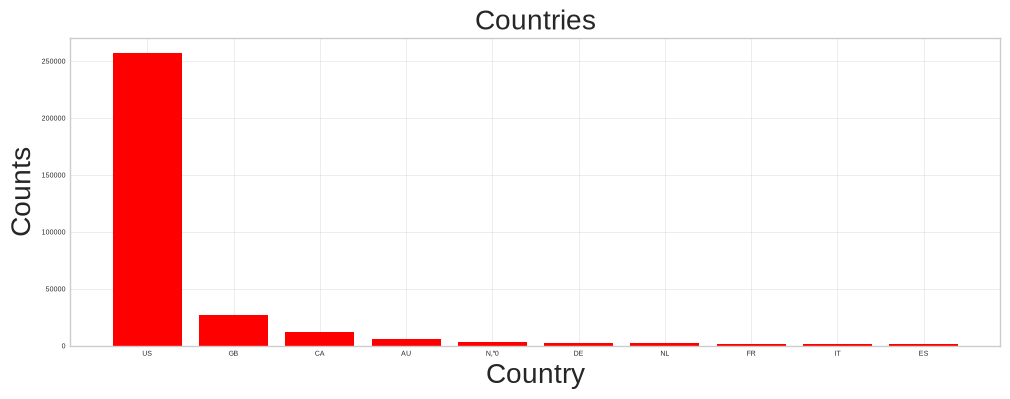

In [34]:
ks_cnt_cur = ksp_db.groupby('country')['country'].count().sort_values(ascending=False).head(10)

plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(12, 4))
plt.bar(ks_cnt_cur.index.values, ks_cnt_cur.values, color="red")
plt.xticks(fontsize=5)
plt.yticks(fontsize=5)

plt.title('Countries', fontsize=20)
plt.xlabel('Country', fontsize=20)
plt.ylabel('Counts', fontsize=20)
plt.show()

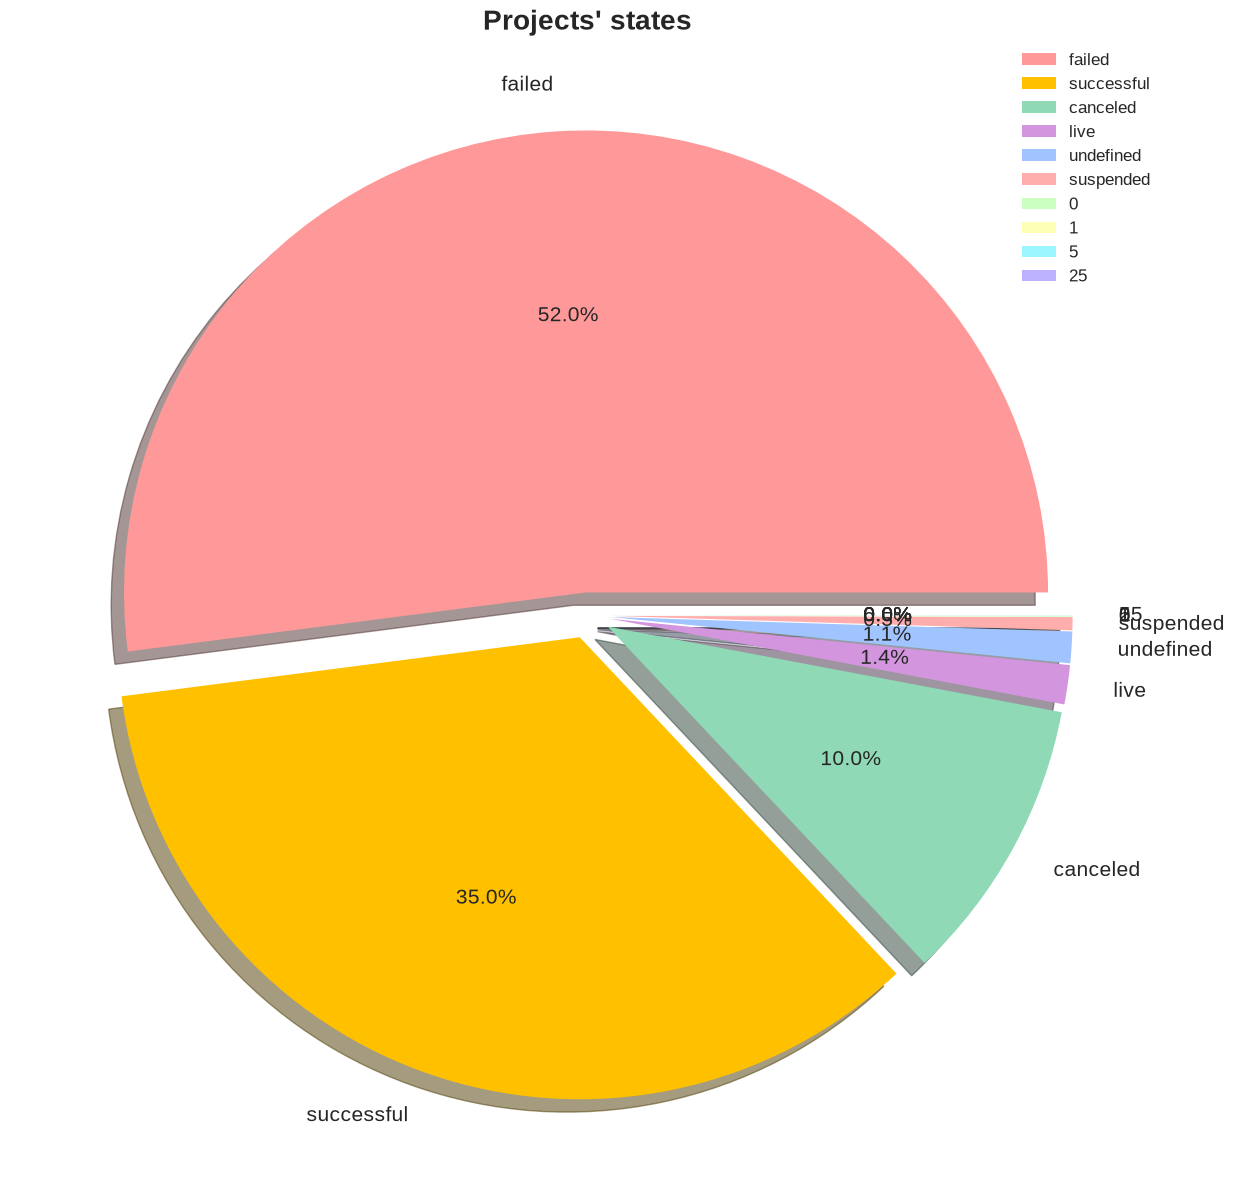

In [35]:
ks_cnt_st = ksp_db.groupby('state')['state'].count().sort_values(ascending=False).head(10)

plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(15, 15))

colors = ['#ff9999', '#ffc000', '#8fd9b6', '#d395de', '#a0c4ff', '#ffadad', '#caffbf', '#fdffb6', '#9bf6ff', '#bdb2ff']
explode = [0.05] * 10

plt.pie(ks_cnt_st.values, labels=ks_cnt_st.index.values,
        autopct='%.1f%%',
        explode=explode,
        shadow=True,
        colors=colors,
        textprops={'fontsize': 15})

plt.title('Projects\' states', fontsize=20, fontweight='bold')
plt.legend(loc='upper right', fontsize=12)
plt.show()

<StringArray>
[    'failed',   'canceled', 'successful',       'live',  'undefined',
  'suspended',       '4262',       '3984',        '525',          '0',
 ...
        '545',       '2356',      '11050',        '865',     '7281.1',
        '296',         '61',        '179',       '2501',       '2634']
Length: 410, dtype: str


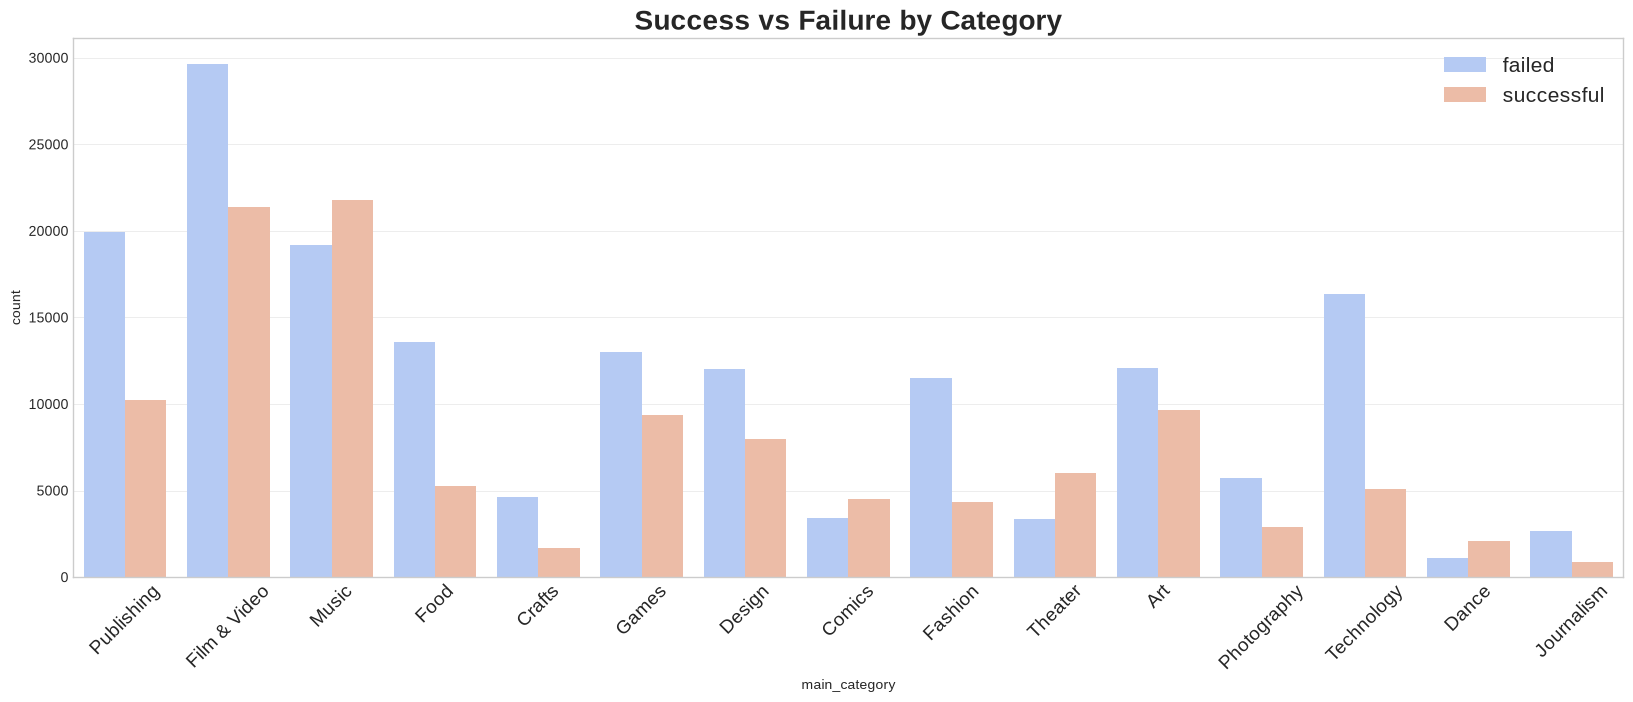

In [36]:
print(ksp_db['state'].unique())
ks_filtered = ksp_db[ksp_db['state'].isin(['successful', 'failed'])]

plt.figure(figsize=(20, 7))
palette1 = sns.color_palette('coolwarm', 2)

sns.countplot(data=ks_filtered, x='main_category', hue='state', palette=palette1)
plt.title('Success vs Failure by Category', fontsize=20, fontweight='bold')
plt.xticks(fontsize=14, rotation=45)
plt.legend(loc='upper right', fontsize=15)
plt.show()